# Train Decision Tree Model

## Motivation
A **Decision Tree** was chosen for this alarm-prediction task for three reasons:

1. **Non-linearity** — alarm patterns are driven by complex threshold combinations (e.g. `alarm_status_1h_ago == 1 AND alarms_count_1h_ago > 5`). Linear models struggle to capture these; a tree splits on exactly such boundaries natively.
2. **Mixed feature types** — the dataset has numeric weather/NLP features alongside binary categorical flags. Decision Trees handle both without requiring standardisation, making the pipeline simpler and easier to interpret.
3. **Interpretability & feature importance** — trees provide native `feature_importances_` (Gini impurity reduction), giving a direct and meaningful ranking of features with no extra computation. This is a key task requirement.

In [1]:
import os
os.chdir("..")

In [13]:
import datetime as dt
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from time import time

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, BaseCrossValidator
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef, precision_score, recall_score, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
def calculate_transition_weights(X, y):
    is_change = X['alarm_status_1h_ago'].values != y.values
    n_same = (~is_change).sum()
    n_change = is_change.sum()
    weight_change = n_same / n_change
    sample_weights = np.where(is_change, weight_change, 1.0)
    return sample_weights

def combined_weights(X, y):
    transition_weights = calculate_transition_weights(X, y)
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    class_w = np.where(y == 1, n_neg / n_pos, 1.0)
    sample_weights = transition_weights * class_w
    return sample_weights

In [27]:
def plot_results(scores, cm, title=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1, 2, 1)
    sns.lineplot(scores[['train_f1', 'test_f1']])
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    ConfusionMatrixDisplay(cm).plot(ax=plt.subplot(1, 2, 2))
    if title:
        plt.suptitle(title)
    plt.show()

In [48]:
from app.db.database import Database


with Database("app/db/database.db") as db:
    new_data = db.get_merged(start_date='2026-04-08')

from sklearn.metrics import precision_recall_curve, auc

def check_on_new_data(pipeline, new_data=new_data):
    X_test = new_data.copy()
    y_test = X_test.pop(target)
    
    y_preds = pipeline.predict(X_test)
    y_pred_probs = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    f1_score_ = f1_score(y_test, y_preds)
    roc_auc = roc_auc_score(y_test, y_pred_probs)
    mcc_score_ = matthews_corrcoef(y_test, y_preds)
    precision_ = precision_score(y_test, y_preds)
    recall_ = recall_score(y_test, y_preds)
    pr_auc = average_precision_score(y_test, y_pred_probs)
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_preds)
    
    # Predictions dataframe
    res = X_test[['region_id', 'time']].copy()
    res['alarm'] = y_test
    res['prediction'] = y_preds
    res['pred_prob_1'] = y_pred_probs
    
    # Metrics dataframe
    metrics_df = pd.DataFrame({
        'f1_score': [f1_score_],
        'roc_auc': [roc_auc],
        'pr_auc': [pr_auc],
        'mcc': [mcc_score_],
        'precision': [precision_],
        'recall': [recall_]
    })
    
    return res, metrics_df, cm

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Георгій\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Commiting


In [91]:
def get_feature_importance(pipeline, base=new_data):
    X_new_hourly = base.drop(columns=target)
    y_new_hourly = base[target]
    mask = ~y_new_hourly.isna()
    X_new_hourly = X_new_hourly[mask]
    y_new_hourly = y_new_hourly[mask]
    
    perm = permutation_importance(
        estimator=pipeline,
        X=X_new_hourly,
        y=y_new_hourly,
        scoring="f1",
        n_repeats=5,
        random_state=42,
        # n_jobs=-1,
    )
    
    importance_df = pd.DataFrame({
        "feature": X_new_hourly.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    
    # Convert to percentages relative to the total absolute importance
    total = importance_df["importance_mean"].abs().sum()
    importance_df["importance_pct"] = (importance_df["importance_mean"] / total * 100).round(2)
    importance_df["importance_std_pct"] = (importance_df["importance_std"] / total * 100).round(2)
    return importance_df[["feature", "importance_pct", "importance_std_pct"]]

In [94]:
def plot_feature_importances(df, title):
    plt.figure(figsize=(10, 8))
    plt.barh(df["feature"][::-1], df["importance_pct"][::-1])
    plt.xlabel("feature importance (percents)")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Loading data

In [5]:
data_path = Path("data/merged/merged_preprocessed.csv")

data = pd.read_csv(data_path)
data["time"] = pd.to_datetime(data["time"], utc=True).dt.tz_convert("Europe/Kyiv")
data = data.sort_values(by=["region_id", "time"])

data = data.drop(columns=["year", "month", "day"], errors="ignore")

data = data.loc[data.time < '2026-04-08']

target = "alarm"

X = data.copy()
y = X.pop(target)

print(f"Dataset shape : {data.shape}")
print(f"Percent alarms: {y.mean():.2%}")

Dataset shape : (821904, 114)
Percent alarms: 20.47%


In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 821904 entries, 0 to 823421
Columns: 114 entries, region_id to is_weekend
dtypes: datetime64[us, Europe/Kyiv](1), float64(72), int64(41)
memory usage: 721.1 MB


In [7]:
data.head()

,region_id,time,alarm,temp,feelslike,humidity,dew,precip,precipprob,preciptype,windspeed,winddir,pressure,visibility,cloudcover,uvindex,conditions,messages_count,has_threat_sum,nlp_артобстрілу,nlp_бпла,nlp_відбій,nlp_відбій_тривоги,nlp_дніпропетровська,nlp_донецька,nlp_запорізька,nlp_нікополь,nlp_нікополь_нікопольська,nlp_нікопольська,nlp_повітряна,nlp_повітряна_тривога,nlp_тривога,nlp_тривоги,nlp_харківська,msg_count_last_3h,msg_count_last_24h,threat_diff_1h,text_length,isw_cluster_0,isw_cluster_1,isw_cluster_2,isw_cluster_3,isw_cluster_4,isw_cluster_5,isw_cluster_6,isw_cluster_7,isw_cluster_8,isw_cluster_9,news_count_7d,news_velocity_30d,dom_cluster_share_7d,dom_cluster_share_30d,centroid_shift_30d,news_velocity_7d,avg_dist_centroid_30d,centroid_shift_7d,anomaly_count_30d,news_count_30d,topic_entropy_30d,avg_dist_centroid_7d,topic_entropy_7d,anomaly_count_7d,alarms_count_1h_ago,alarms_count_2h_ago,alarms_count_3h_ago,alarms_count_4h_ago,alarms_count_5h_ago,alarms_count_6h_ago,alarms_count_7h_ago,alarms_count_8h_ago,alarms_count_9h_ago,alarms_count_10h_ago,alarms_count_11h_ago,alarms_count_12h_ago,alarms_count_13h_ago,alarms_count_14h_ago,alarms_count_15h_ago,alarms_count_16h_ago,alarms_count_17h_ago,alarms_count_18h_ago,alarms_count_19h_ago,alarms_count_20h_ago,alarms_count_21h_ago,alarms_count_22h_ago,alarms_count_23h_ago,alarms_count_24h_ago,alarm_status_1h_ago,alarm_status_2h_ago,alarm_status_3h_ago,alarm_status_4h_ago,alarm_status_5h_ago,alarm_status_6h_ago,alarm_status_7h_ago,alarm_status_8h_ago,alarm_status_9h_ago,alarm_status_10h_ago,alarm_status_11h_ago,alarm_status_12h_ago,alarm_status_13h_ago,alarm_status_14h_ago,alarm_status_15h_ago,alarm_status_16h_ago,alarm_status_17h_ago,alarm_status_18h_ago,alarm_status_19h_ago,alarm_status_20h_ago,alarm_status_21h_ago,alarm_status_22h_ago,alarm_status_23h_ago,alarm_status_24h_ago,neighbor_alarm_count,hour,day_of_week,is_weekend
0,3,2022-03-27 00:00:00+02:00,0,7.0,3.1,68.99,1.7,0.0,0.0,0.0,24.5,312.8,1018.0,24.1,55.8,0.0,4.0,19,7,0,0,7,7,2,0,0,0,0,0,6,6,7,7,4,42,352,5,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6,1
1,3,2022-03-27 01:00:00+02:00,0,5.7,1.2,44.72,-5.4,0.0,0.0,0.0,26.6,326.8,1019.0,24.1,4.2,0.0,0.0,12,8,0,0,0,0,2,0,2,0,0,0,8,8,8,0,2,37,360,1,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6,1
2,3,2022-03-27 02:00:00+02:00,0,3.8,-0.9,43.48,-7.5,0.0,0.0,0.0,23.8,322.6,1021.0,24.1,0.0,0.0,0.0,23,10,0,0,11,11,2,0,2,0,0,0,10,10,12,11,2,54,378,2,11717,0,0,0,0,0,0,0,0,0,1,10,48,0.7,0.620000,0.533511,2,0.471807,0.173424,5,50,0.664064,0.388121,0.610864,1,13.0,5.0,3.0,1.0,8.0,7.0,13.0,22.0,22.0,22.0,13.0,13.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,10.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,6,1
3,3,2022-03-28 04:00:00+03:00,0,-1.3,-1.3,56.25,-8.9,0.0,0.0,0.0,4.3,228.8,1029.0,24.1,18.8,0.0,0.0,11,10,0,0,0,0,2,0,2,0,0,0,9,9,9,0,2,26,275,10,13953,0,0,0,0,0,0,0,0,0,1,10,45,0.7,0.632653,0.484262,2,0.465249,0.179787,5,49,0.657529,0.386532,0.610864,1,8.0,2.0,4.0,5.0,10.0,24.0,15.0,3.0,0.0,0.0,3.0,3.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0,0
4,3,2022-03-28 05:00:00+03:00,0,-1.3,-1.3,56.69,-8.8,0.0,0.0,0.0,3.6,199.3,1029.0,24.1,87.8,0.0,4.0,9,1,0,0,6,6,2,0,2,0,0,0,1,1,2,6,2,27,283,-9,13953,0,0,0,0,0,0,0,0,0,1,10,45,0.7,0.632653,0.484262,2,0.465249,0.179787,5,49,0.657529,

In [63]:
mask = X.time >= '2025'
X_from_2025 = X.loc[mask].reset_index(drop=True)
y_from_2025 = y.loc[mask].reset_index(drop=True)

X_from_2025.shape, y_from_2025.shape

((243170, 113), (243170,))

# Feature groups

Decision Trees are **invariant to feature scaling** — splits are rank-based, not magnitude-based.  
Therefore no `StandardScaler` is used. Categorical columns are label-encoded integers and pass through as-is.

In [8]:
NON_FEATURES = {"time", "region_id"}

# Auto-detect feature types
cat_cols = [
    c for c in X.select_dtypes(include=["category", "object"], exclude=["datetime"]).columns
    if c not in NON_FEATURES
]
num_cols = [
    c for c in X.select_dtypes(include="number").columns
    if c not in cat_cols and c not in NON_FEATURES
]

feature_cols = num_cols + cat_cols

print(f"Numeric     : {len(num_cols)}")
print(f"Categorical : {len(cat_cols)}")
print(f"Total       : {len(feature_cols)}")

Numeric     : 111
Categorical : 0
Total       : 111


# Evaluating function

In [9]:
def evaluate_model(pipeline, X=X, y=y, n_splits: int = 10, gap: int = 24, max_train_size=None, weights_func=None):
    
    f1_train_scores = []
    f1_test_scores  = []
    roc_auc_test_scores = []
    pr_auc_test_scores = []
    mcc_test_scores = []
    precision_test_scores = []
    recall_test_scores = []
    all_y_true = []
    all_y_pred = []
    all_y_proba = []
    training_start = time()
    
    unique_hours = X["time"].sort_values().unique()
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, max_train_size=max_train_size)
    
    for fold, (train_idx, test_idx) in enumerate(tscv.split(unique_hours)):
        train_hours = unique_hours[train_idx]
        test_hours  = unique_hours[test_idx]
        train_mask = X["time"].isin(train_hours) 
        test_mask  = X["time"].isin(test_hours)
               
        X_train = X[train_mask]
        y_train = y[train_mask]
        X_test  = X[test_mask]
        y_test  = y[test_mask]
        
        sample_weights = weights_func(X_train, y_train) if weights_func else None
        
        pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)
        y_pred_train = pipeline.predict(X_train)
        y_pred_test  = pipeline.predict(X_test)
        y_proba_test = pipeline.predict_proba(X_test)[:, 1] 

        train_score = f1_score(y_train, y_pred_train)
        f1_train_scores.append(train_score)
        test_score = f1_score(y_test, y_pred_test)
        f1_test_scores.append(test_score)
        
        roc_auc = roc_auc_score(y_test, y_proba_test)
        roc_auc_test_scores.append(roc_auc)
        
        pr_auc = average_precision_score(y_test, y_proba_test)
        pr_auc_test_scores.append(pr_auc)

        mcc = matthews_corrcoef(y_test, y_pred_test)
        mcc_test_scores.append(mcc)
        precision = precision_score(y_test, y_pred_test)
        precision_test_scores.append(precision)
        recall = recall_score(y_test, y_pred_test)
        recall_test_scores.append(recall)
        
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred_test)
        all_y_proba.extend(y_proba_test)

    print("------------- Evaluation Results -------------")
    print(f"Train F1       : {np.mean(f1_train_scores):.3f} ± {np.std(f1_train_scores):.3f}")
    print(f"Test  F1       : {np.mean(f1_test_scores):.3f} ± {np.std(f1_test_scores):.3f}")
    print(f"Test  Precision: {np.mean(precision_test_scores):.3f} ± {np.std(precision_test_scores):.3f}")
    print(f"Test  Recall   : {np.mean(recall_test_scores):.3f} ± {np.std(recall_test_scores):.3f}")
    print(f"Test  ROC_AUC  : {np.mean(roc_auc_test_scores):.3f} ± {np.std(roc_auc_test_scores):.3f}")
    print(f"Test  PR_AUC   : {np.mean(pr_auc_test_scores):.3f} ± {np.std(pr_auc_test_scores):.3f}")
    print(f"Test  MCC      : {np.mean(mcc_test_scores):.3f} ± {np.std(mcc_test_scores):.3f}")
    print(f"")
    print(f"Completed in: {time() - training_start:.2f}s.")
    
    scores = pd.DataFrame({
        "train_f1":       f1_train_scores,
        "test_f1":        f1_test_scores, 
        "test_precision": precision_test_scores,
        "test_recall":    recall_test_scores,
        "test_roc_auc":   roc_auc_test_scores,
        "test_pr_auc":    pr_auc_test_scores,
        "test_mcc":       mcc_test_scores,
    })
    
    overall_cm = confusion_matrix(all_y_true, all_y_pred)
    return scores, overall_cm

## Baseline evaluation (before tuning)

In [32]:
model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42, class_weight="balanced")
preprocessor = ColumnTransformer(transformers=[
    # ('label_encode', LabelEncoder(), cat_cols),
    # ('scale', StandardScaler(), num_cols),
    ("drop_cols", "drop", ["time"]),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [39]:
scores, cm = evaluate_model(
    pipeline,
    max_train_size=450*24,
)

------------- Evaluation Results -------------
Train F1       : 0.667 ± 0.064
Test  F1       : 0.643 ± 0.098
Test  Precision: 0.558 ± 0.112
Test  Recall   : 0.764 ± 0.084
Test  ROC_AUC  : 0.876 ± 0.046
Test  PR_AUC   : 0.767 ± 0.088
Test  MCC      : 0.548 ± 0.095

Completed in: 64.82s.


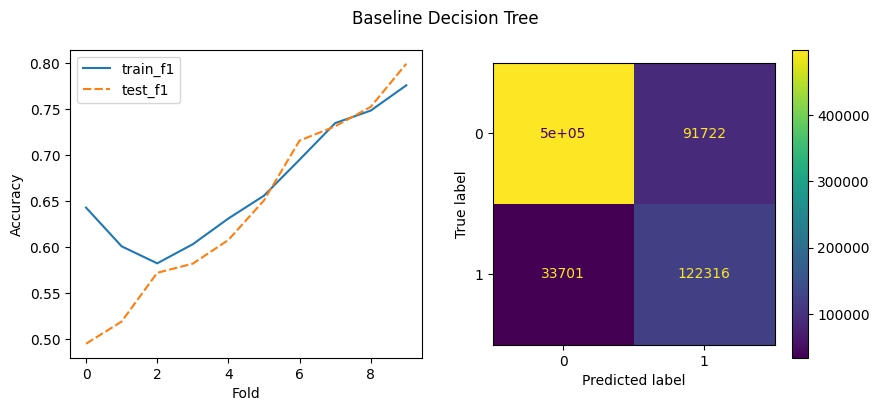

In [40]:
plot_results(scores[['train_f1', 'test_f1']], cm, "Baseline Decision Tree")

Add custom weightening function because of highly imbalanced data

In [45]:
model = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

scores, cm = evaluate_model(
    pipeline,
    max_train_size=450*24,
    weights_func=combined_weights
)

------------- Evaluation Results -------------
Train F1       : 0.391 ± 0.118
Test  F1       : 0.397 ± 0.127
Test  Precision: 0.276 ± 0.114
Test  Recall   : 0.810 ± 0.038
Test  ROC_AUC  : 0.743 ± 0.040
Test  PR_AUC   : 0.598 ± 0.060
Test  MCC      : 0.173 ± 0.140

Completed in: 62.76s.


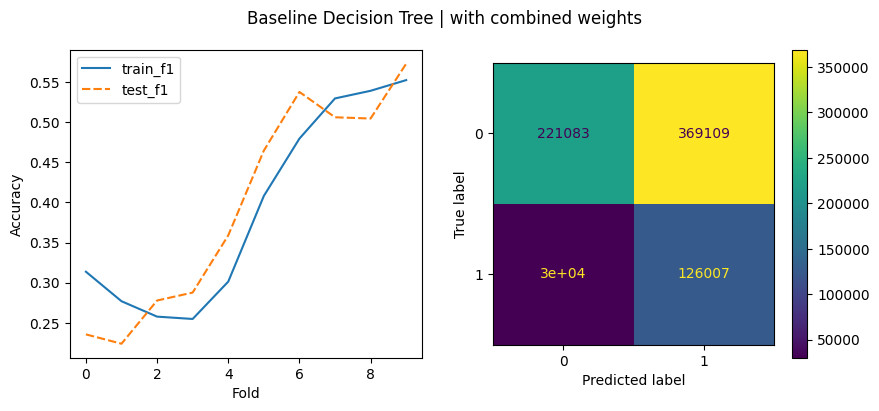

In [46]:
plot_results(scores[['train_f1', 'test_f1']], cm, "Baseline Decision Tree | with combined weights")

Using combined weights significantly dropped accuracy

Training on more recent data can improve results due to less noise.

In [54]:
scores, cm = evaluate_model(
    pipeline,
    X_from_2025, y_from_2025,
    max_train_size=450*24,
    weights_func=combined_weights
)

Task was destroyed but it is pending!
task: <Task pending name='Task-424' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\PythonProjects\AlarmForecast\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-425' coro=<Kernel.shell_main() running at C:\PythonProjects\AlarmForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\PythonProjects\AlarmForecast\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-425' coro=<Kernel.shell_main() running at C:\PythonProjects\AlarmForecast\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


------------- Evaluation Results -------------
Train F1       : 0.586 ± 0.025
Test  F1       : 0.541 ± 0.044
Test  Precision: 0.421 ± 0.044
Test  Recall   : 0.762 ± 0.044
Test  ROC_AUC  : 0.795 ± 0.027
Test  PR_AUC   : 0.654 ± 0.039
Test  MCC      : 0.342 ± 0.057

Completed in: 44.06s.


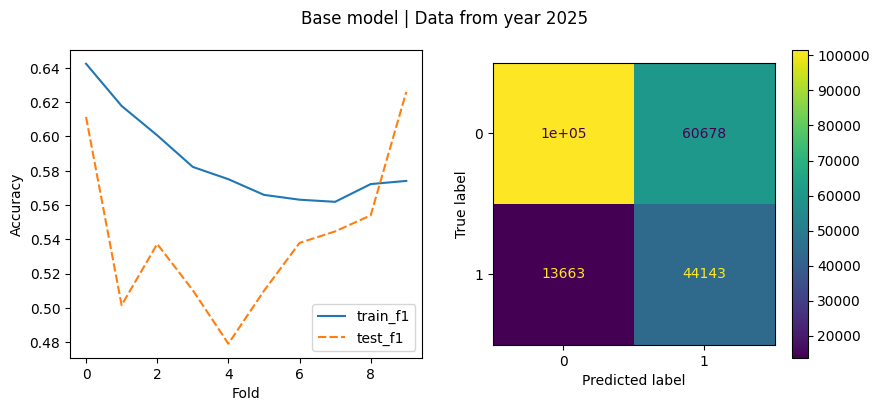

In [55]:
plot_results(scores, cm, "Base model | Data from year 2025")

In [56]:
weights = combined_weights(X_from_2025, y_from_2025)
pipeline.fit(X_from_2025, y_from_2025, model__sample_weight=weights)
res, metrics, cm = check_on_new_data(pipeline)

In [57]:
display(metrics)

,f1_score,roc_auc,pr_auc,mcc,precision,recall
0,0.622389,0.814477,0.672892,0.41086,0.48538,0.867164


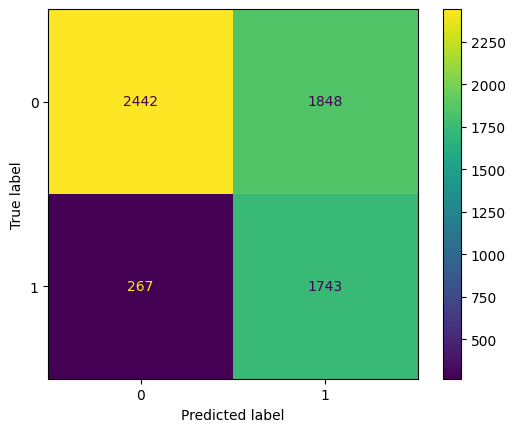

In [58]:
ConfusionMatrixDisplay(cm).plot()

In [59]:
with pd.option_context("display.max_rows", None):
    display(res.loc[res.region_id == 31])

,region_id,time,alarm,prediction,pred_prob_1
6048,31,2026-04-09 00:00:00+03:00,0,0,0.467280
6049,31,2026-04-09 01:00:00+03:00,0,0,0.467280
6050,31,2026-04-09 02:00:00+03:00,0,1,0.770659
6051,31,2026-04-09 03:00:00+03:00,0,1,0.655072
6052,31,2026-04-09 04:00:00+03:00,0,0,0.467280
6053,31,2026-04-09 05:00:00+03:00,1,0,0.467280
6054,31,2026-04-09 06:00:00+03:00,1,0,0.491902
6055,31,2026-04-09 07:00:00+03:00,0,0,0.200311
6056,31,2026-04-09 08:00:00+03:00,0,1,0.712586
6057,31,2026-04-09 09:00:00+03:00,0,0,0.356952


# Hyperparameter Tuning - GridSearchCV

## Scoring metrics

| Metric | Why used                                                                                                                                               |
|--------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| **`f1`** | Primary metric - balances Precision and Recall for the 20/80 imbalanced split                                                                          |
| **`average_precision`** | Best complement for imbalanced binary classification - AUPRC summarises P-R trade-off across all thresholds without being skewed by the large TN count |

**Refit:** `f1` - consistent with `evaluate_model` across all models in this project.

Need to define custom `RegionAwareTimeSeriesSplit` that will correctly handle our data. It will chose train and test hours and apply them across all regions.

In [16]:
class RegionAwareTimeSeriesSplit(BaseCrossValidator):
    """
    TimeSeriesSplit that splits on unique timestamps,
    ensuring all regions have identical train/test hour boundaries.
    """
    def __init__(self, times, n_splits=10, gap=24, max_train_hours=450*24):
        self.times = np.array(times)               # the 'time' column from X
        self.n_splits = n_splits
        self.gap = gap
        self.max_train_hours = max_train_hours

    def split(self, X, y=None, groups=None):
        unique_times = np.unique(self.times)
        n = len(unique_times)

        # Mirror TimeSeriesSplit logic but on timestamp
        test_size = n // (self.n_splits + 1)

        for i in range(self.n_splits):
            test_end   = n - (self.n_splits - 1 - i) * test_size
            test_start = test_end - test_size
            train_end  = test_start - self.gap

            if train_end <= 0:
                continue

            train_start = max(0, train_end - self.max_train_hours)

            # Get the actual timestamp boundaries
            train_times = unique_times[train_start:train_end]
            test_times  = unique_times[test_start:test_end]

            # Map back to row indices
            train_idx = np.where(np.isin(self.times, train_times))[0]
            test_idx  = np.where(np.isin(self.times, test_times))[0]

            yield train_idx, test_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

In [70]:
custom_cv = RegionAwareTimeSeriesSplit(
    times=X_from_2025["time"].values,          # pass the time column
    n_splits=10,
    gap=24,
    max_train_hours=450 * 24,
)

model = DecisionTreeClassifier(random_state=42)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

weights = combined_weights(X_from_2025, y_from_2025)

param_grid = {
    "model__criterion":         ["gini", "entropy"],
    "model__max_depth":         [5, 10, 20],
    "model__min_samples_split": [20, 100],
    "model__min_samples_leaf":  [20, 50, 100],
    "model__max_features":      [None, "sqrt"],
    # "model__class_weight":      ["balanced"],
}
# 2x3x2x3x2x1 = 72 combinations x 3 folds = 216 fits

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring={"f1": "f1", "average_precision": "average_precision"},
    refit="f1",
    cv=custom_cv,
    n_jobs=4,
    verbose=2,
    return_train_score=True,
)

t0 = time()
grid_search.fit(X_from_2025, y_from_2025, model__sample_weight=weights)
print(f"\nGridSearchCV completed in: {time() - t0:.2f}s")

Fitting 10 folds for each of 72 candidates, totalling 720 fits

GridSearchCV completed in: 527.52s


In [71]:
print("Best parameters:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.replace('classifier__', '')}: {val}")

best_idx = grid_search.best_index_
print(f"\nBest CV F1    : {grid_search.best_score_:.4f}")
print(f"Best CV AUPRC : {grid_search.cv_results_['mean_test_average_precision'][best_idx]:.4f}")

Best parameters:
  model__criterion: entropy
  model__max_depth: 20
  model__max_features: None
  model__min_samples_leaf: 20
  model__min_samples_split: 20

Best CV F1    : 0.5800
Best CV AUPRC : 0.6837


In [72]:
cv_results = pd.DataFrame(grid_search.cv_results_)

top10 = (
    cv_results
    .sort_values("mean_test_f1", ascending=False)
    .head(10)
    [[
        "param_model__criterion",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "param_model__max_features",
        "mean_test_f1",
        "mean_test_average_precision",
    ]]
    .rename(columns=lambda c: c.replace("param_classifier__", "").replace("mean_test_", ""))
    .reset_index(drop=True)
)

top10

,param_model__criterion,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,f1,average_precision
0,entropy,20,20,20,NaN,0.580036,0.683702
1,gini,20,20,20,NaN,0.571671,0.671786
2,entropy,20,100,20,NaN,0.563302,0.668837
3,gini,20,20,50,NaN,0.559615,0.659743
4,gini,20,100,50,NaN,0.559615,0.659743
5,gini,20,100,20,NaN,0.559552,0.663868
6,entropy,20,20,50,NaN,0.558650,0.663010
7,entropy,20,100,50,NaN,0.558650,0.663010
8,gini,20,100,100,NaN,0.545183,0.643442
9,gini,20,20,100,NaN,0.545183,0.643442


# Tuned model - full evaluation

Auto-selects the better model (GridSearch vs baseline) by Test F1.

In [75]:
gs_best = grid_search.best_estimator_

scores_tuned, cm_tuned = evaluate_model(gs_best, X_from_2025, y_from_2025, weights_func=combined_weights)

# Pick the better model by Test F1
if np.mean(scores_tuned["test_f1"]) >= np.mean(scores["test_f1"]):
    tuned_pipeline = gs_best
    final_cm    = cm_tuned
    print("\n[+] GridSearch model selected (better Test F1)")
else:
    tuned_pipeline = pipeline
    final_cm    = cm
    print("\n[!] Baseline model selected (GridSearch did not improve Test F1)")
    print("    Reason: max_features restriction hurt single-tree performance.")

------------- Evaluation Results -------------
Train F1       : 0.710 ± 0.019
Test  F1       : 0.583 ± 0.024
Test  Precision: 0.490 ± 0.024
Test  Recall   : 0.722 ± 0.035
Test  ROC_AUC  : 0.831 ± 0.012
Test  PR_AUC   : 0.689 ± 0.026
Test  MCC      : 0.411 ± 0.023

Completed in: 53.33s.

[+] GridSearch model selected (better Test F1)


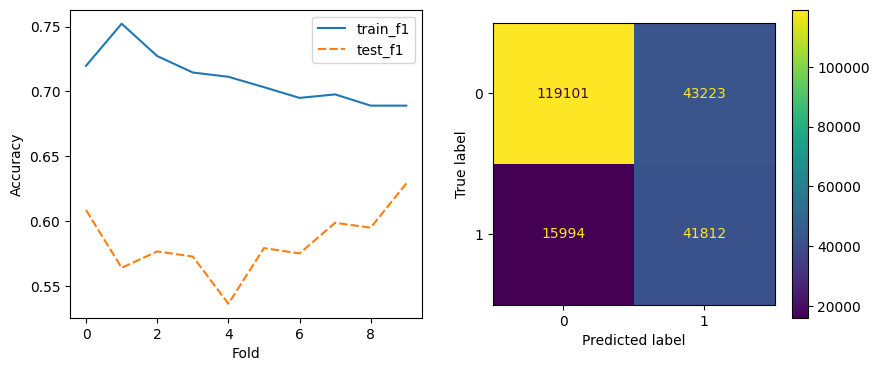

In [76]:
plot_results(scores_tuned, cm_tuned)

# Check on new data

Evaluates the final model on unseen data fetched from the database (post-cutoff: `2026-04-08` onwards).  
Mirrors `check_on_new_data` from the LGBM notebook for direct comparison.

In [82]:
tuned_pipeline.fit(X_from_2025, y_from_2025, model__sample_weight=combined_weights(X_from_2025, y_from_2025))
res, metrics, cm = check_on_new_data(tuned_pipeline)

In [83]:
display(metrics)

,f1_score,roc_auc,pr_auc,mcc,precision,recall
0,0.633614,0.823446,0.684163,0.431302,0.540161,0.766169


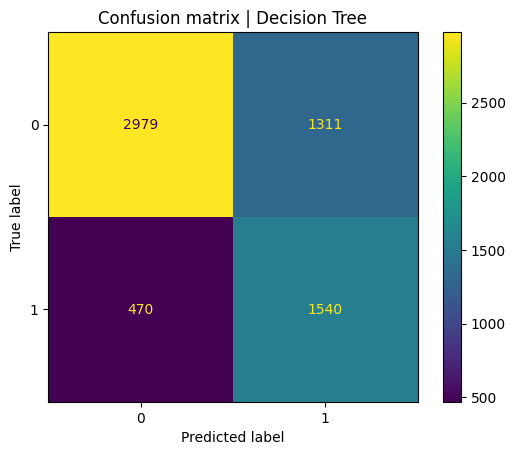

In [102]:
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion matrix | Decision Tree")
plt.show()

In [85]:
with pd.option_context("display.max_rows", None):
    display(res.loc[res.region_id == 31])

,region_id,time,alarm,prediction,pred_prob_1
6048,31,2026-04-09 00:00:00+03:00,0,1,0.578131
6049,31,2026-04-09 01:00:00+03:00,0,1,0.578131
6050,31,2026-04-09 02:00:00+03:00,0,0,0.000000
6051,31,2026-04-09 03:00:00+03:00,0,1,0.715969
6052,31,2026-04-09 04:00:00+03:00,0,0,0.000000
6053,31,2026-04-09 05:00:00+03:00,1,0,0.000000
6054,31,2026-04-09 06:00:00+03:00,1,0,0.134555
6055,31,2026-04-09 07:00:00+03:00,0,0,0.015528
6056,31,2026-04-09 08:00:00+03:00,0,1,0.715969
6057,31,2026-04-09 09:00:00+03:00,0,0,0.000000


# Top 20 features and weights

Decision Tree uses **Gini impurity reduction** (`feature_importances_`) as the feature weight.  
Measures how much each feature reduces impurity across all splits, weighted by samples reaching each split.  
Values sum to 1.0 - higher means more important.

In [89]:
feature_names = X.drop(columns=["time"]).columns.tolist()

importances = tuned_pipeline.named_steps["model"].feature_importances_

feat_imp = (
    pd.DataFrame({"feature": feature_names, "weight": importances})
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)

top20 = feat_imp.head(20)
top20

,feature,weight
0,nlp_відбій_тривоги,0.096358
1,neighbor_alarm_count,0.089809
2,alarm_status_23h_ago,0.081911
3,alarm_status_1h_ago,0.076023
4,region_id,0.062905
5,alarms_count_1h_ago,0.019097
6,hour,0.017732
7,nlp_відбій,0.016502
8,centroid_shift_7d,0.016081
9,pressure,0.014423


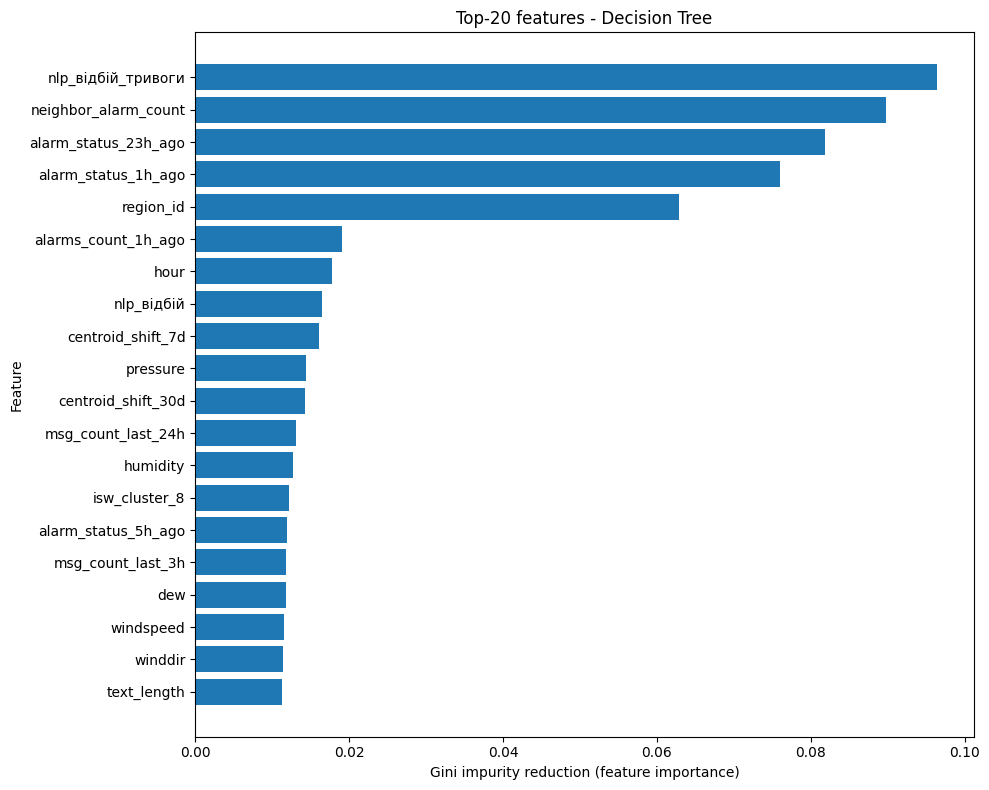

In [90]:
plt.figure(figsize=(10, 8))
plt.barh(top20["feature"][::-1], top20["weight"][::-1])
plt.xlabel("Gini impurity reduction (feature importance)")
plt.ylabel("Feature")
plt.title("Top-20 features - Decision Tree")
plt.tight_layout()
plt.show()

In [ ]:
feature_importances = get_feature_importance(tuned_pipeline)

In [101]:
feature_importances.head(20)

,feature,importance_pct,importance_std_pct
109,neighbor_alarm_count,20.79,0.74
0,region_id,15.57,0.72
90,alarm_status_6h_ago,8.15,0.25
107,alarm_status_23h_ago,6.69,0.94
85,alarm_status_1h_ago,2.48,0.55
94,alarm_status_10h_ago,2.39,0.30
87,alarm_status_3h_ago,2.22,0.35
97,alarm_status_13h_ago,2.13,0.64
16,messages_count,1.67,0.11
34,msg_count_last_24h,1.65,0.07


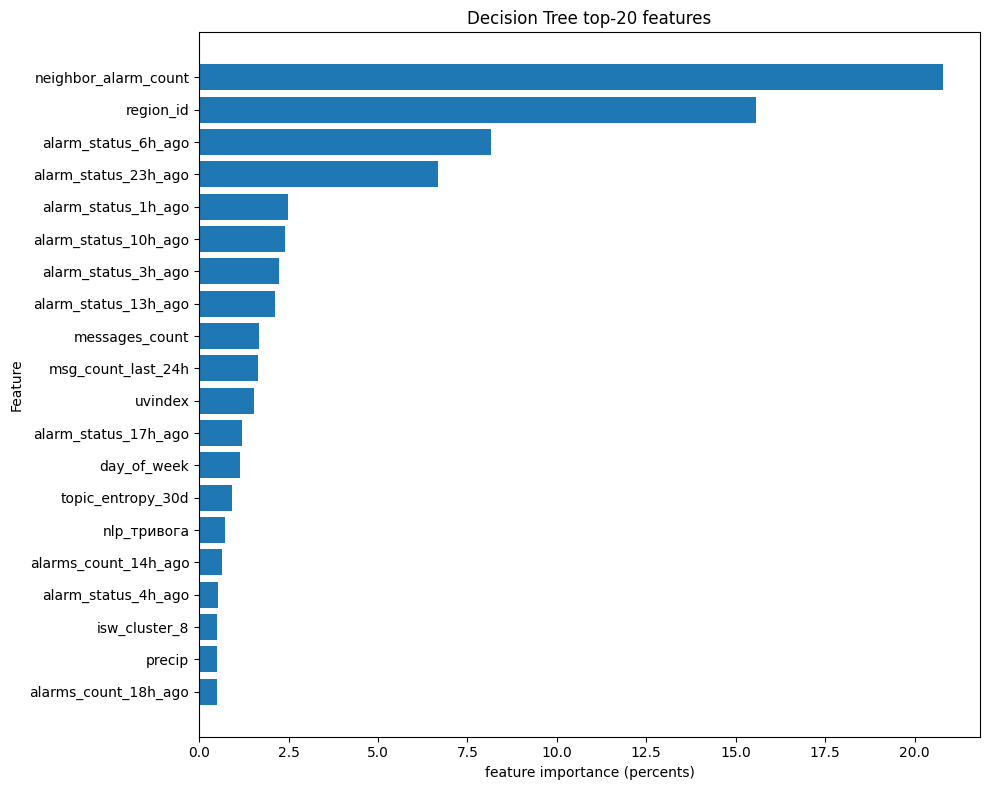

In [97]:
plot_feature_importances(feature_importances.head(20), "Decision Tree top-20 features")

# Save model as pickle

In [99]:
# Refit final model on the full dataset before saving
X_full = X.drop(columns=["time", "region_id"])
tuned_model.fit(X_from_2025, y_from_2025)

model_path = Path("app/models/decision_tree_v3.pkl")

with open(model_path, "wb") as f:
    pickle.dump(tuned_model, f)

print(f"Model saved -> {model_path.resolve()}")

Model saved -> C:\PythonProjects\AlarmForecast\app\models\decision_tree_v3.pkl
